# Chicago Neighborhoods — Exploration & Charts

Charts for the Medium post: two choropleths (Driver_Score, Transit_Score), a quadrant scatter plot, and top-10 bar charts. Run `python3 main.py` from the project root first so `data/processed/` is populated.

In [1]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))
import config
from src import data_fetcher

scores = pd.read_csv(config.SCORES_CSV)
ca_gdf = data_fetcher.get_community_area_boundaries()
geo = ca_gdf.merge(scores, on=["area_numbe", "community"])
geo.head()

Matplotlib is building the font cache; this may take a moment.


,area_numbe,community,geometry,area_sq_mi_x,rep_point,total_population,area_sq_mi_y,Driver_Score,Driver_Rank,Transit_Score,...,crash_rate_per_1k,ped_cyclist_crash_rate_per_1k,nearest_ramp_distance_mi,nearest_l_stop_distance_mi,population_density_per_sq_mi,grocery_density_per_sq_mi,walkable_amenity_density_per_sq_mi,transit_ridership_pct,zero_vehicle_pct,affordability_index
0,1,Rogers Park,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ...",1.838696,POINT (-87.67099 42.0105),55711.0,1.838696,58.865289,60,68.074048,...,24.333914,1.531714,1.996876,0.300210,30299.190370,2.719318,52.754779,28.077155,37.201205,3.992699
1,2,West Ridge,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ...",3.530658,POINT (-87.69395 42.00139),79265.0,3.530658,61.633819,55,56.635058,...,30.644042,1.551757,2.388566,1.521291,22450.489660,2.549100,22.941899,12.507607,13.331573,4.308815
2,3,Uptown,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41....",2.334985,POINT (-87.65593 41.96615),57464.0,2.334985,72.399905,19,70.848838,...,26.317927,2.198478,0.411823,0.154918,24610.009376,2.997878,66.381586,34.872231,42.059925,4.649205
3,4,Lincoln Square,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41...",2.559413,POINT (-87.68959 41.97603),42271.0,2.559413,65.327519,49,65.936130,...,26.125082,1.908322,1.925787,0.683553,16515.899000,1.172144,45.322899,26.009860,21.649112,4.870020
4,5,North Center,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ...",2.046537,POINT (-87.68496 41.94686),35814.0,2.046537,77.819201,5,70.333489,...,28.303643,1.600864,1.112811,0.531923,17499.808610,2.931782,69.385515,20.008549,12.605566,7.345377


## Choropleth maps

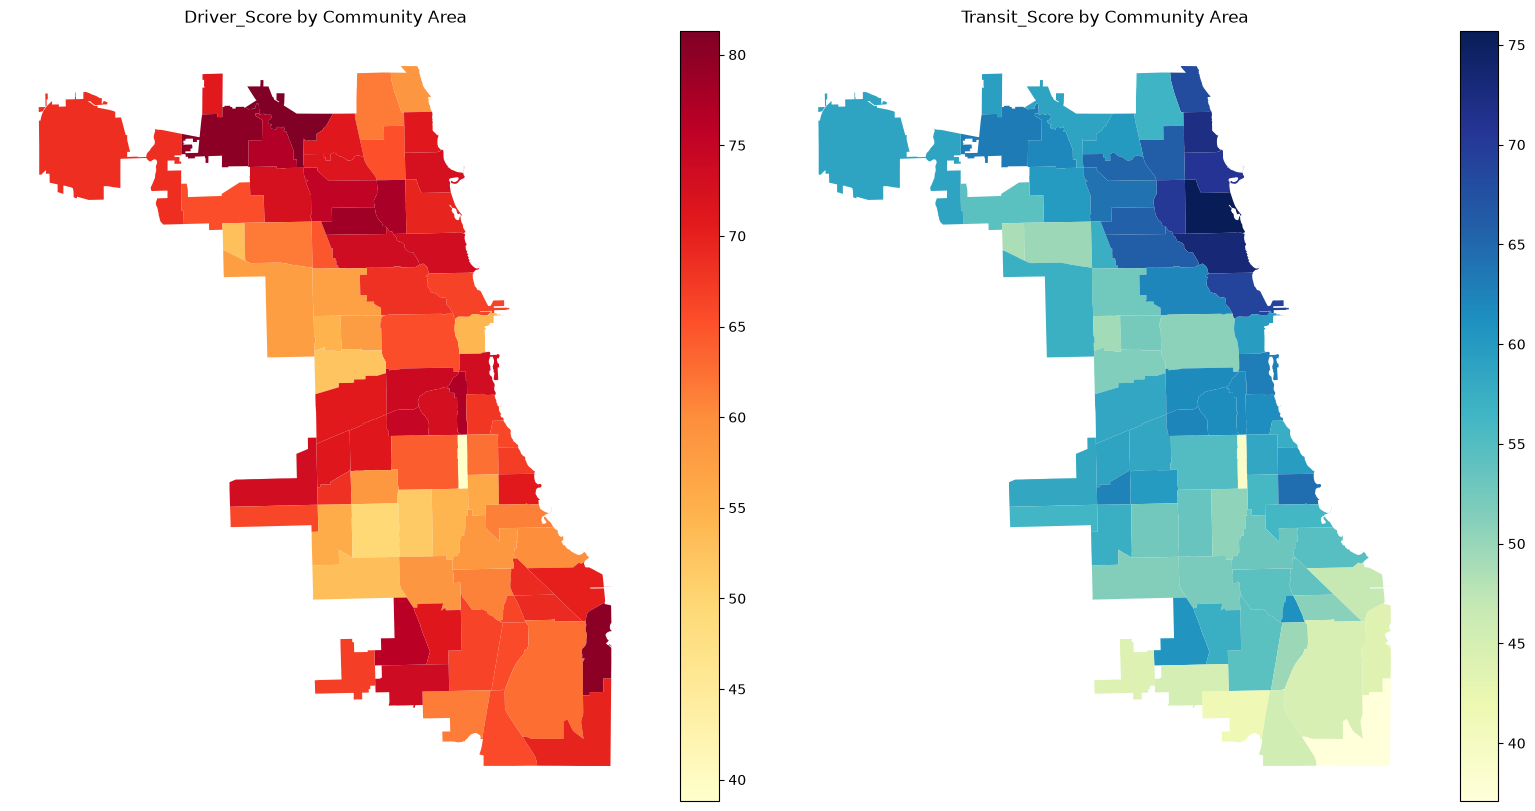

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
_ = geo.plot(column="Driver_Score", cmap="YlOrRd", legend=True, ax=axes[0])
_ = axes[0].set_title("Driver_Score by Community Area")
_ = axes[0].axis("off")

_ = geo.plot(column="Transit_Score", cmap="YlGnBu", legend=True, ax=axes[1])
_ = axes[1].set_title("Transit_Score by Community Area")
_ = axes[1].axis("off")

_ = plt.tight_layout()

## Driver vs. Transit quadrant scatter

Split on the citywide median of each score: top-right = all-around winners, bottom-left = underserved by both, and the two off-diagonal quadrants are the car-dependent / transit-only trade-off areas.

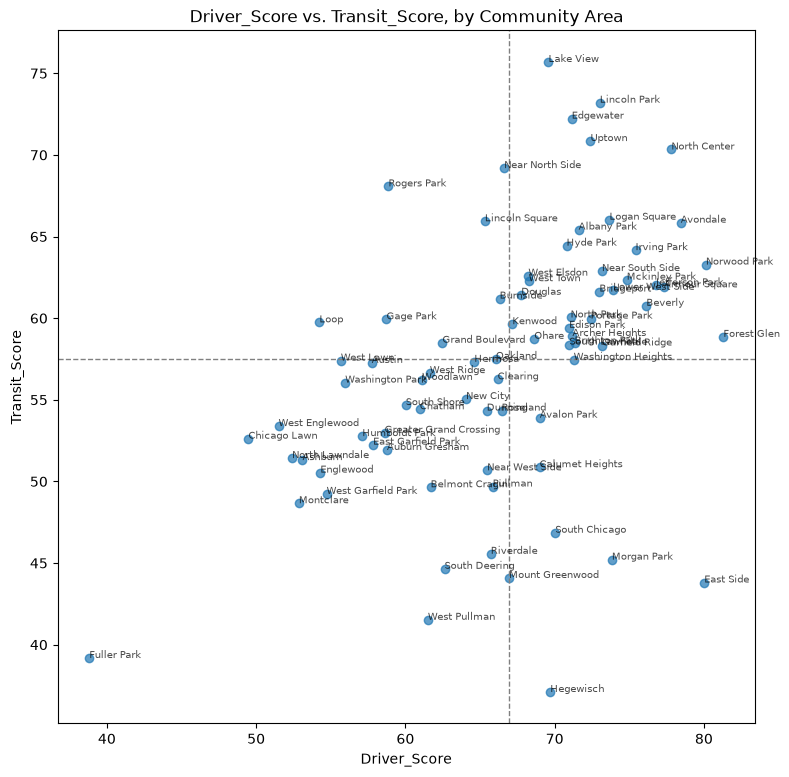

In [3]:
driver_med = scores["Driver_Score"].median()
transit_med = scores["Transit_Score"].median()

fig, ax = plt.subplots(figsize=(9, 9))
_ = ax.scatter(scores["Driver_Score"], scores["Transit_Score"], alpha=0.7)
for _, row in scores.iterrows():
    _ = ax.annotate(row["community"], (row["Driver_Score"], row["Transit_Score"]), fontsize=7, alpha=0.7)
_ = ax.axvline(driver_med, color="grey", linestyle="--", linewidth=1)
_ = ax.axhline(transit_med, color="grey", linestyle="--", linewidth=1)
_ = ax.set_xlabel("Driver_Score")
_ = ax.set_ylabel("Transit_Score")
_ = ax.set_title("Driver_Score vs. Transit_Score, by Community Area")

## Top 10 per persona

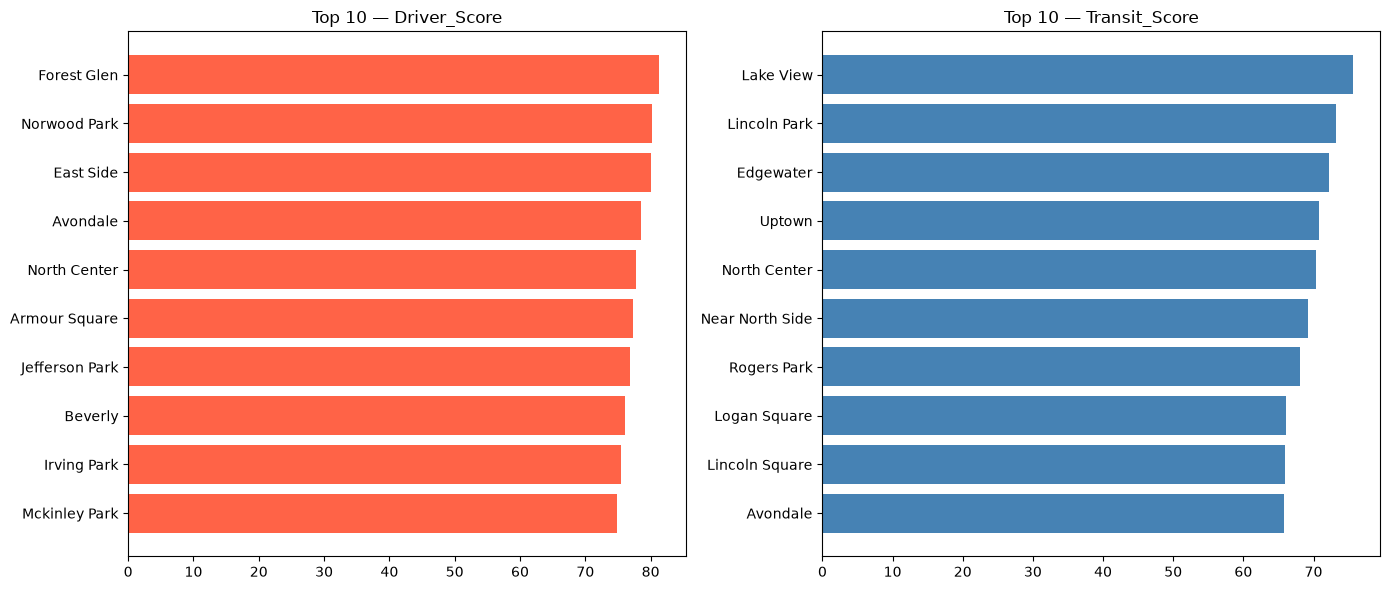

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_driver = scores.sort_values("Driver_Score", ascending=False).head(10)
_ = axes[0].barh(top_driver["community"][::-1], top_driver["Driver_Score"][::-1], color="tomato")
_ = axes[0].set_title("Top 10 — Driver_Score")

top_transit = scores.sort_values("Transit_Score", ascending=False).head(10)
_ = axes[1].barh(top_transit["community"][::-1], top_transit["Transit_Score"][::-1], color="steelblue")
_ = axes[1].set_title("Top 10 — Transit_Score")

_ = plt.tight_layout()